# 📊 Data Visualization in Python

**Goal:** learn 7 essential chart types using Matplotlib and Seaborn —
and learn **when** to use each one. Choosing the right chart is a key data analyst skill.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")  # clean background grid for every chart

## Load the data

5000 employees with department, age, salary, experience and gender.

In [2]:
df = pd.read_csv("data/employees.csv")

print("Shape (rows, columns):", df.shape)
print()
print(df.head())
print()
print(df.describe().round(1))

Shape (rows, columns): (5000, 6)

   EmployeeID   Department  Age  Salary  ExperienceYears  Gender
0           1  Engineering   40  210100               18    Male
1           2           HR   31   96000                7  Female
2           3    Marketing   27   86400                6  Female
3           4        Sales   37  162100               15    Male
4           5  Engineering   42  200500               18  Female

       EmployeeID     Age    Salary  ExperienceYears
count      5000.0  5000.0    5000.0           5000.0
mean       2500.5    32.1  127765.0             10.0
std        1443.5     6.1   49703.9              6.0
min           1.0    22.0   30000.0              0.0
25%        1250.8    27.0   86000.0              5.0
50%        2500.5    32.0  127750.0             10.0
75%        3750.2    37.0  169300.0             15.0
max        5000.0    44.0  247400.0             20.0


## Chart 1 — Line chart 📈

**When to use it:** to show a **trend** — how a number changes across a continuous variable (like time or experience).
Here: does average salary rise with experience?

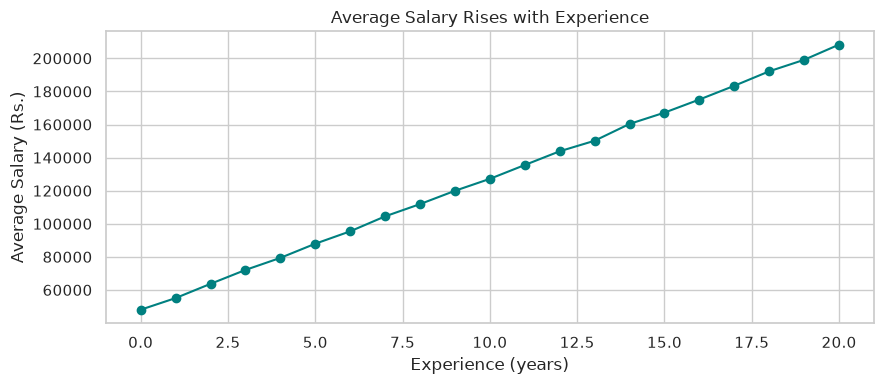

In [3]:
# Average salary for each year of experience
trend = df.groupby("ExperienceYears")["Salary"].mean()

plt.figure(figsize=(9, 4))
plt.plot(trend.index, trend.values, marker="o", color="teal")
plt.title("Average Salary Rises with Experience")
plt.xlabel("Experience (years)")
plt.ylabel("Average Salary (Rs.)")
plt.tight_layout()
plt.show()

## Chart 2 — Bar chart 📊

**When to use it:** to **compare** numbers across categories.
Here: which department pays the highest average salary?

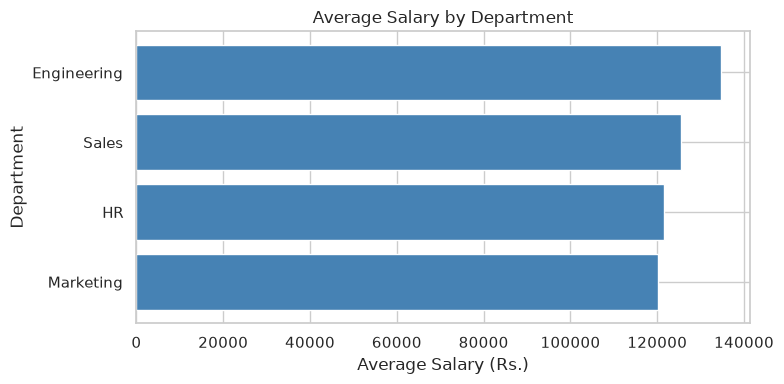

In [4]:
avg_sal = df.groupby("Department")["Salary"].mean().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(avg_sal.index, avg_sal.values, color="steelblue")
plt.title("Average Salary by Department")
plt.xlabel("Average Salary (Rs.)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

## Chart 3 — Histogram 🔔

**When to use it:** to see the **distribution** of a single numeric variable — where most values fall.
Here: how are employee ages distributed?

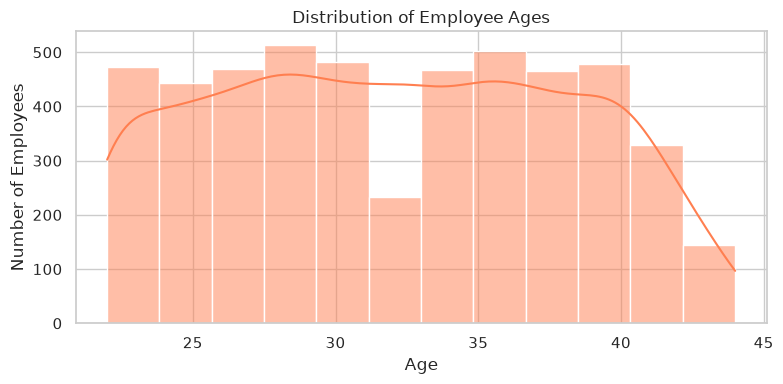

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], bins=12, kde=True, color="coral")
plt.title("Distribution of Employee Ages")
plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

## Chart 4 — Boxplot 📦

**When to use it:** to compare the **spread** of a number across groups — and spot **outliers** (dots outside the box).
Here: salary spread inside each department.

/tmp/ipykernel_5939/1420168957.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Department", y="Salary", palette="pastel")


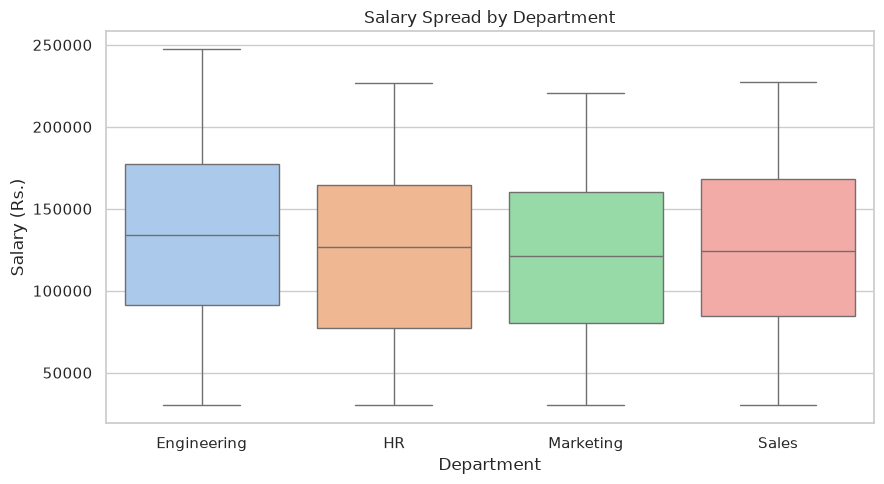

In [6]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="Department", y="Salary", palette="pastel")
plt.title("Salary Spread by Department")
plt.xlabel("Department")
plt.ylabel("Salary (Rs.)")
plt.tight_layout()
plt.show()

## Chart 5 — Scatter plot ✨

**When to use it:** to see the **relationship** between two numeric variables.
Here: experience vs salary — plus a regression line showing the trend.

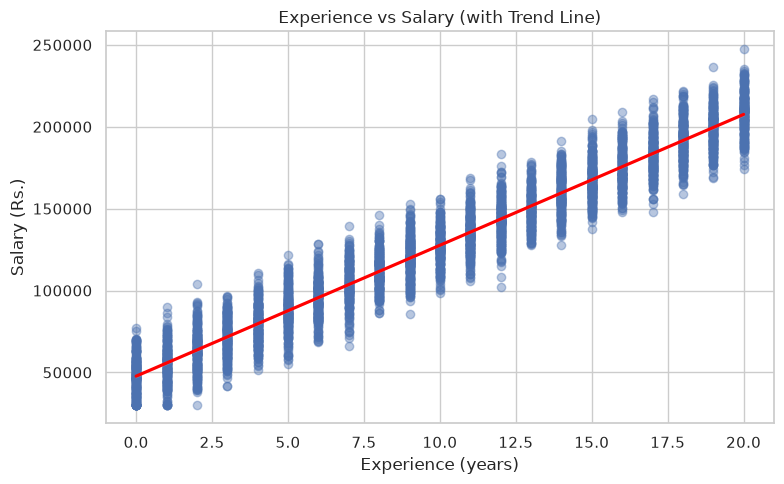

In [7]:
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x="ExperienceYears", y="Salary",
            scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Experience vs Salary (with Trend Line)")
plt.xlabel("Experience (years)")
plt.ylabel("Salary (Rs.)")
plt.tight_layout()
plt.show()

## Chart 6 — Heatmap 🔥

**When to use it:** to see **correlations** between many numeric columns at a glance.
Dark red = strong positive link, dark blue = strong negative link.

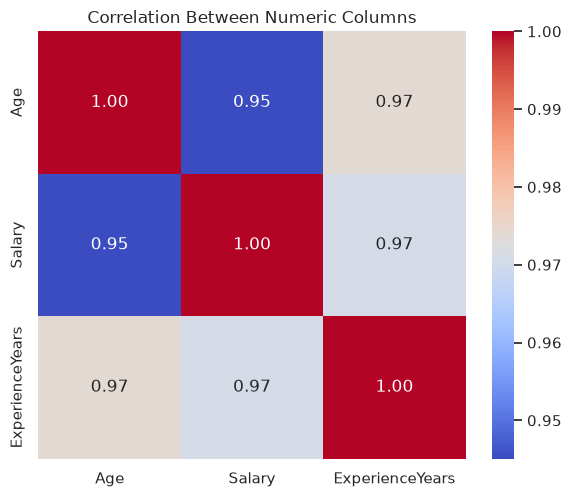

In [8]:
corr = df[["Age", "Salary", "ExperienceYears"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Between Numeric Columns")
plt.tight_layout()
plt.show()

## Chart 7 — Countplot 🧮

**When to use it:** to **count** rows per category — with `hue`, split each bar by a second category.
Here: headcount per department, split by gender.

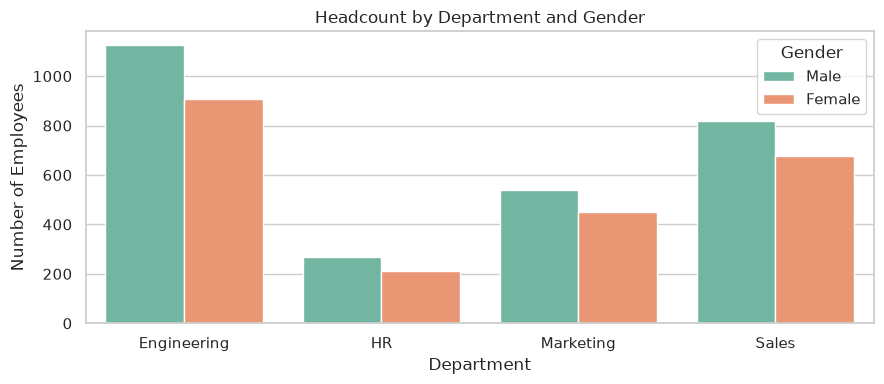

In [9]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x="Department", hue="Gender", palette="Set2")
plt.title("Headcount by Department and Gender")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()

## ✅ Done!

You now know 7 chart types and **when** to use each:
line (trend) → bar (compare) → histogram (distribution) → boxplot (spread) →
scatter (relationship) → heatmap (correlations) → countplot (counts).